In [51]:
import pandas as pd
import numpy as np
import category_encoders as ce
from sklearn import preprocessing
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
heart_df = pd.read_csv('data/heart.csv')
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [43]:
# Создайте новый признак old, где 1 — при возрасте пациента более 60 лет.
heart_df['old'] = heart_df['age'].apply(lambda x: 1 if x > 60 else 0)
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,old
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0


In [44]:
heart_df['old'].sum()

np.int64(79)

In [45]:
# Создайте новый признак trestbps_mean, который будет обозначать норму давления в среднем для его возраста и пола. trestbps — систолическое артериальное давление в состоянии покоя.

conditions = [
    (heart_df['age'] < 21) & (heart_df['sex'] == 1),
    (heart_df['age'] < 21) & (heart_df['sex'] == 0),

    (heart_df['age'] >= 20) & (heart_df['age'] < 31) & (heart_df['sex'] == 1),
    (heart_df['age'] >= 20) & (heart_df['age'] < 31) & (heart_df['sex'] == 0),

    (heart_df['age'] >= 31) & (heart_df['age'] < 41) & (heart_df['sex'] == 1),
    (heart_df['age'] >= 31) & (heart_df['age'] < 41) & (heart_df['sex'] == 0),

    (heart_df['age'] >= 41) & (heart_df['age'] < 51) & (heart_df['sex'] == 1),
    (heart_df['age'] >= 41) & (heart_df['age'] < 51) & (heart_df['sex'] == 0),

    (heart_df['age'] >= 51) & (heart_df['age'] < 61) & (heart_df['sex'] == 1),
    (heart_df['age'] >= 51) & (heart_df['age'] < 61) & (heart_df['sex'] == 0),

    (heart_df['age'] >= 61) & (heart_df['sex'] == 1),
    (heart_df['age'] >= 61) & (heart_df['sex'] == 0)
]

choices = [
    123, 116,
    126, 120,
    129, 127,
    135, 137,
    142, 144,
    142, 159
]

heart_df['trestbps_mean'] = np.select(conditions, choices, default=None)

heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,old,trestbps_mean
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,1,142
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0,129
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0,137
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0,142
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0,144


In [46]:
heart_df['trestbps_mean'][300]

142

In [47]:
encoder = ce.OneHotEncoder(cols=['cp', 'restecg', 'slope', 'ca', 'thal'], use_cat_names=True)
encoder_bin = encoder.fit_transform(heart_df[['cp', 'restecg', 'slope', 'ca', 'thal']])
heart_df = pd.concat([heart_df, encoder_bin], axis=1)
heart_df = heart_df.drop(['cp', 'restecg', 'slope', 'ca', 'thal'], axis=1)
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            303 non-null    int64  
 1   sex            303 non-null    int64  
 2   trestbps       303 non-null    int64  
 3   chol           303 non-null    int64  
 4   fbs            303 non-null    int64  
 5   thalach        303 non-null    int64  
 6   exang          303 non-null    int64  
 7   oldpeak        303 non-null    float64
 8   target         303 non-null    int64  
 9   old            303 non-null    int64  
 10  trestbps_mean  303 non-null    object 
 11  cp_3.0         303 non-null    int64  
 12  cp_2.0         303 non-null    int64  
 13  cp_1.0         303 non-null    int64  
 14  cp_0.0         303 non-null    int64  
 15  restecg_0.0    303 non-null    int64  
 16  restecg_1.0    303 non-null    int64  
 17  restecg_2.0    303 non-null    int64  
 18  slope_0.0 

In [48]:
heart_df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,old,...,slope_1.0,ca_0.0,ca_2.0,ca_1.0,ca_3.0,ca_4.0,thal_1.0,thal_2.0,thal_3.0,thal_0.0
0,63,1,145,233,1,150,0,2.3,1,1,...,0,1,0,0,0,0,1,0,0,0
1,37,1,130,250,0,187,0,3.5,1,0,...,0,1,0,0,0,0,0,1,0,0
2,41,0,130,204,0,172,0,1.4,1,0,...,0,1,0,0,0,0,0,1,0,0
3,56,1,120,236,0,178,0,0.8,1,0,...,0,1,0,0,0,0,0,1,0,0
4,57,0,120,354,0,163,1,0.6,1,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241,0,123,1,0.2,0,0,...,1,1,0,0,0,0,0,0,1,0
299,45,1,110,264,0,132,0,1.2,0,0,...,1,1,0,0,0,0,0,0,1,0
300,68,1,144,193,1,141,0,3.4,0,1,...,1,0,1,0,0,0,0,0,1,0
301,57,1,130,131,0,115,1,1.2,0,0,...,1,0,0,1,0,0,0,0,1,0


In [49]:
r_scaler = preprocessing.RobustScaler()

scaled_trestbp = r_scaler.fit_transform(heart_df[['trestbps']])
heart_df['trestbps'] = scaled_trestbp

scaled_chol = r_scaler.fit_transform(heart_df[['chol']])
heart_df['chol'] = scaled_chol

scaled_thalach = r_scaler.fit_transform(heart_df[['thalach']])
heart_df['thalach'] = scaled_thalach

scaled_oldpeak = r_scaler.fit_transform(heart_df[['oldpeak']])
heart_df['oldpeak'] = scaled_oldpeak

scaled_trestbp_mean = r_scaler.fit_transform(heart_df[['trestbps_mean']])
heart_df['trestbps_mean'] = scaled_trestbp_mean

heart_df.describe()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,old,...,slope_1.0,ca_0.0,ca_2.0,ca_1.0,ca_3.0,ca_4.0,thal_1.0,thal_2.0,thal_3.0,thal_0.0
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,...,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.081188,0.098646,0.148515,-0.103173,0.326733,0.149752,0.544554,0.260726,...,0.462046,0.577558,0.125413,0.214521,0.066007,0.016502,0.059406,0.547855,0.386139,0.006601
std,9.082101,0.466011,0.876907,0.816232,0.356198,0.704774,0.469794,0.725672,0.498835,0.439757,...,0.499382,0.494765,0.331734,0.411169,0.248704,0.127605,0.236774,0.498528,0.487668,0.081110
min,29.000000,0.000000,-1.800000,-1.795276,0.000000,-2.523077,0.000000,-0.500000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,-0.500000,-0.456693,0.000000,-0.600000,0.000000,-0.500000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,55.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,61.000000,1.000000,0.500000,0.543307,0.000000,0.400000,1.000000,0.500000,1.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,77.000000,1.000000,3.500000,5.102362,1.000000,1.507692,1.000000,3.375000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

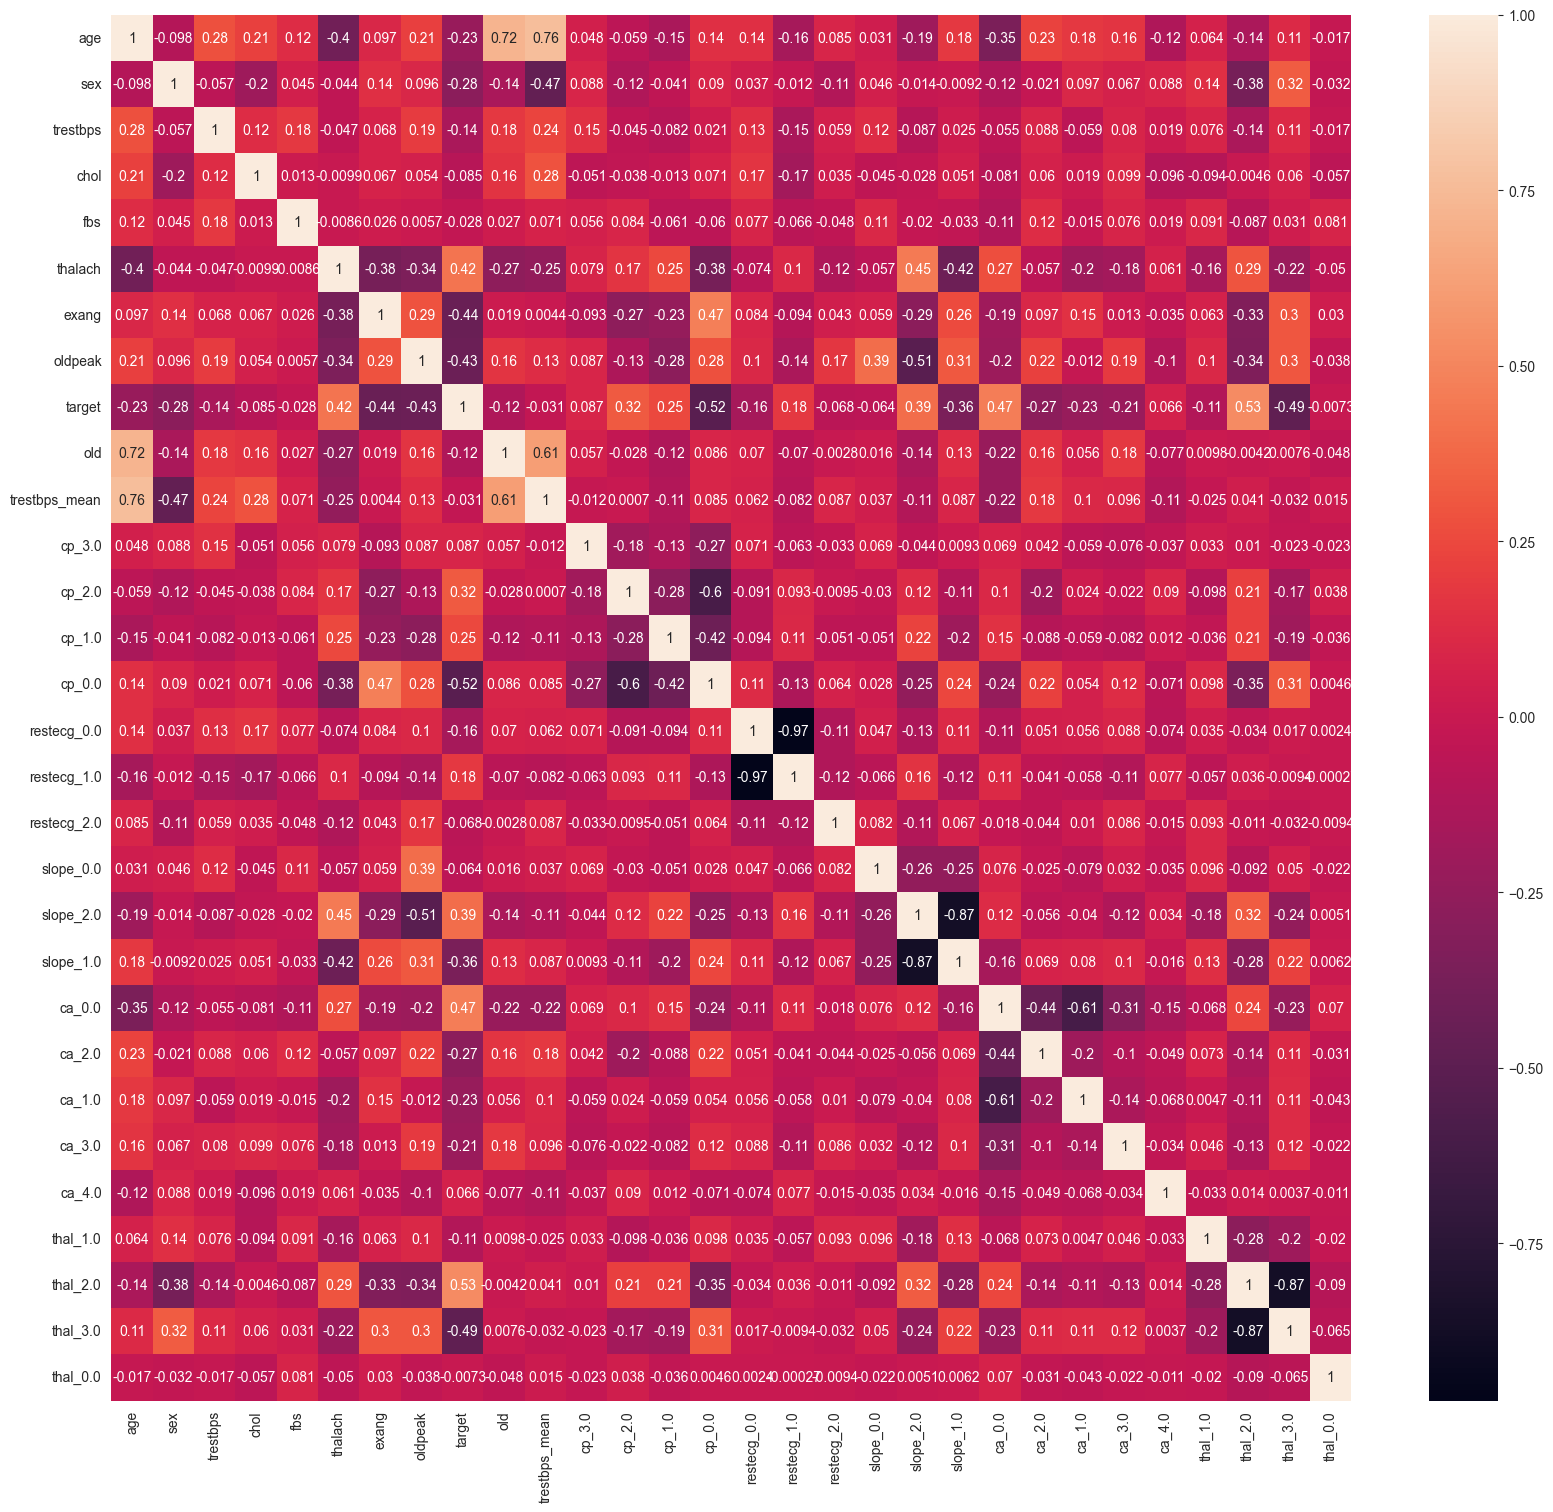

In [58]:
fig, (ax1) = plt.subplots(ncols=1, figsize=(20, 18))
sns.heatmap(heart_df.corr(), ax=ax1, annot=True)